# Week 5 - Exercise
### Notebook created by Jonathan Penava

In general penguins are not sexually dimorphic.  This means that both males and females look alike.  Usually you can tell the difference between males and females by measuring various parts of the penguin like their bill size, their weight, and flipper length.  Getting the exact sex of the penguin by checking genitals can be difficult, and harmful to the animal if not done carefully by someone who is trained.  
<br><br>
In this exercise you are going to read in a set of data about penguin measurements from the seaborn library.  Train a decision tree algorithm to determine if the penguin is male or female.  You will have to analyze the data and determine how to adjust the values accordingly.  I have provided a few lines of code to get you started.
<br><br>
Print the classification report at the end to show how accurate your model is.

Do not drop any columns from your dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset('penguins')

#Uncomment these one at a time to get their info
penguins["species"].unique()
penguins["island"].unique()
penguins["sex"].unique()



<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [2]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins.replace("Adelie", 0, inplace=True)
penguins.replace("Chinstrap", 1, inplace=True)
penguins.replace("Gentoo", 2, inplace=True)

penguins.replace("Torgersen", 0, inplace=True)
penguins.replace("Biscoe", 1, inplace=True)
penguins.replace("Dream", 2, inplace=True)

penguins.replace("Male", 0, inplace=True)
penguins.replace("Female", 1, inplace=True)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,0,39.1,18.7,181.0,3750.0,0
1,0,0,39.5,17.4,186.0,3800.0,1
2,0,0,40.3,18.0,195.0,3250.0,1
3,0,0,NaN,NaN,NaN,NaN,NaN
4,0,0,36.7,19.3,193.0,3450.0,1
...,...,...,...,...,...,...,...
339,2,1,NaN,NaN,NaN,NaN,NaN
340,2,1,46.8,14.3,215.0,4850.0,1
341,2,1,50.4,15.7,222.0,5750.0,0
342,2,1,45.2,14.8,212.0,5200.0,1


In [4]:
penguins.dropna(axis=0, inplace=True)


In [5]:
X = penguins.drop("sex", axis=1)
y = penguins["sex"].values


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=87
)


In [7]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)


ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87        53
         1.0       0.84      0.89      0.87        47

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



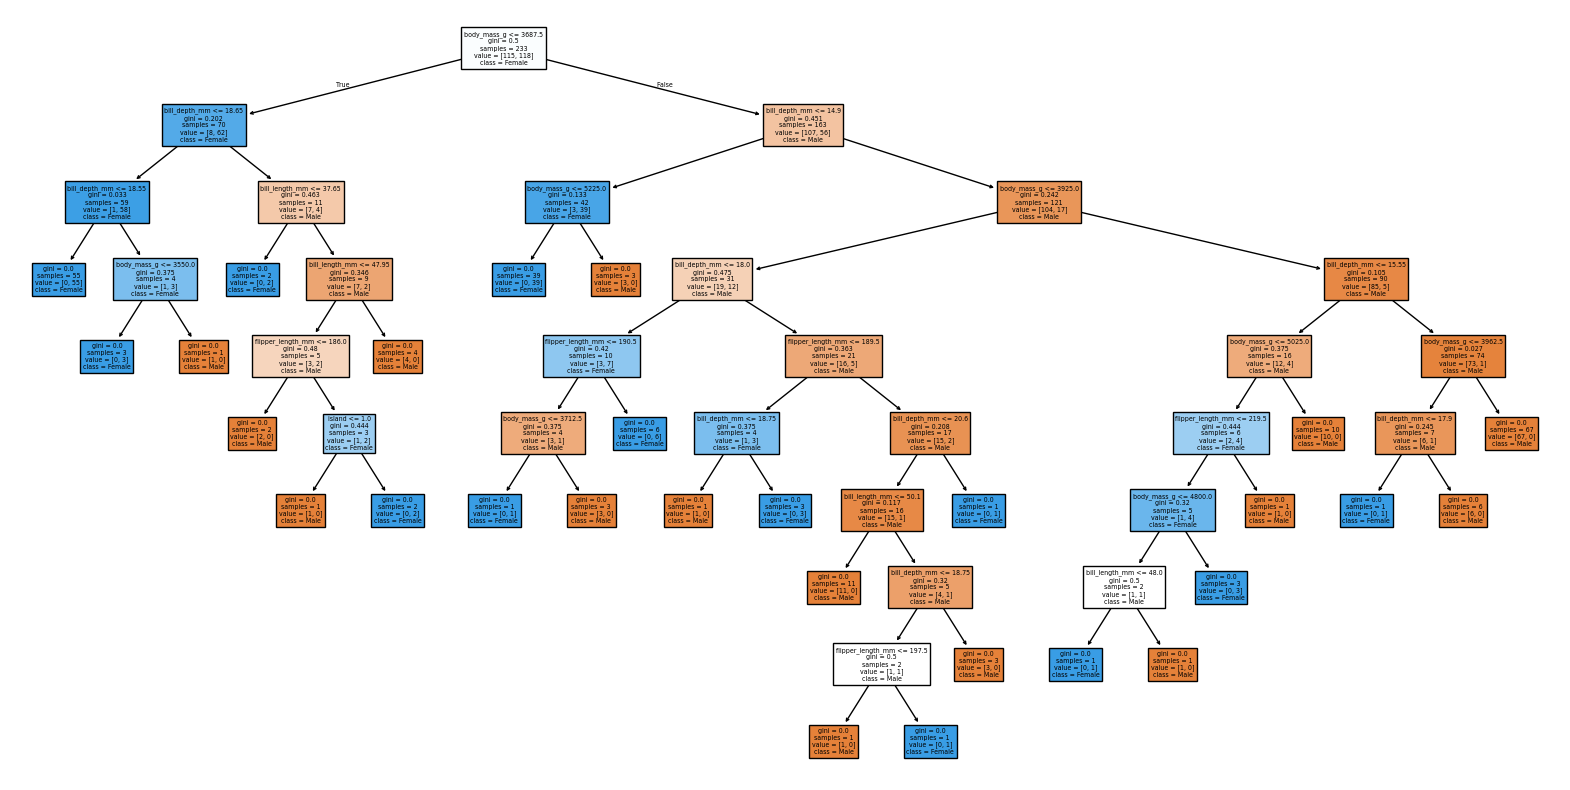

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
fn = list(X.columns)
cn = ["Male", "Female"]
plot_tree(dtree, filled=True, feature_names=fn, class_names=cn)
plt.show()
